In [ ]:
# CELL 1: Imports and Load Dataset
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print("Training images shape :", x_train.shape)
print("Training labels shape :", y_train.shape)
print("Test images shape     :", x_test.shape)
print("Test labels shape     :", y_test.shape)
print("Pixel value range     :", x_train.min(), "–", x_train.max())
print("Classes               :", class_names)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 18s 0us/step
Training images shape : (50000, 32, 32, 3)
Training labels shape : (50000, 1)
Test images shape     : (10000, 32, 32, 3)
Test labels shape     : (10000, 1)
Pixel value range     : 0 – 255
Classes               : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
#CELL 3

# CELL 7 from overall pipeline: Class names and safety category mapping
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

safety_category = {
    'automobile': 'Vehicle', 'truck': 'Vehicle',
    'bird': 'Animal', 'cat': 'Animal', 'deer': 'Animal',
    'dog': 'Animal', 'horse': 'Animal',
    'airplane': 'Other', 'ship': 'Other', 'frog': 'Other'
}

for name in class_names:
    print(f"{name:12s} -> {safety_category[name]}")

airplane     -> Other
automobile   -> Vehicle
bird         -> Animal
cat          -> Animal
deer         -> Animal
dog          -> Animal
frog         -> Other
horse        -> Animal
ship         -> Other
truck        -> Vehicle


In [ ]:
# CELL 6:
# MEMBER 2: Encoding Categorical Variables (One-Hot Encoding)
# Step 1: Look at the current label format (plain integers 0-9)
print("Label before encoding:", y_train[0])
print("Unique classes:", np.unique(y_train))

# Step 2: Convert labels into one-hot vectors for the CNN
# e.g. label 6 becomes [0,0,0,0,0,0,1,0,0,0]
y_train_encoded = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test_encoded = tf.keras.utils.to_categorical(y_test, num_classes=10)

print("Label after encoding:", y_train_encoded[0])
print("Shape after encoding:", y_train_encoded.shape)

Label before encoding: [6]
Unique classes: [0 1 2 3 4 5 6 7 8 9]
Label after encoding: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
Shape after encoding: (50000, 10)


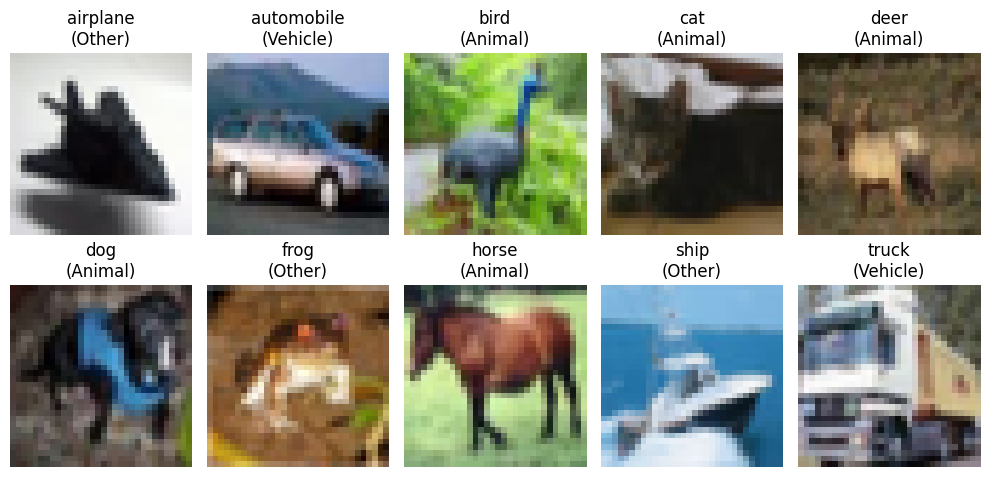

In [ ]:
# CELL 8: Visualize one sample image per class
plt.figure(figsize=(10, 5))
for i, name in enumerate(class_names):
    idx = np.where(y_train.flatten() == i)[0][0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[idx])
    plt.title(f"{name}\n({safety_category[name]})")
    plt.axis('off')
plt.tight_layout()
plt.show()